In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X, _ = make_blobs(
    n_samples=50,
    centers=3,
    cluster_std=1.0,
    random_state=42
)
Z = linkage(X, method='ward')

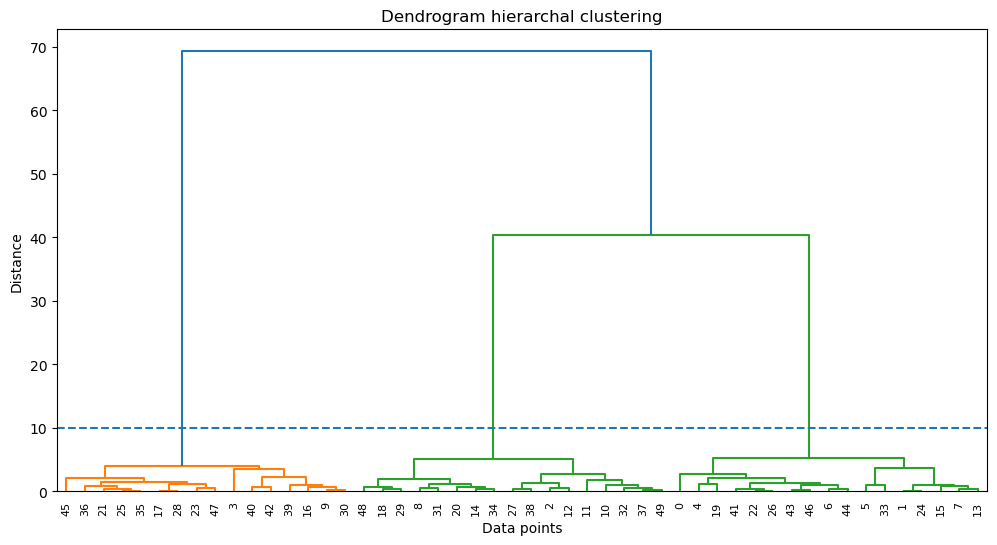

In [8]:
plt.figure(figsize = (12,6))
dendrogram(Z)
plt.title("Dendrogram hierarchal clustering")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.axhline(y=10, linestyle = '--')
plt.show()

In [10]:
k = 3
clusters = fcluster(Z, t =k, criterion="maxclust")
print("Clusters Assignment", clusters)

Clusters Assignment [3 3 2 1 3 3 3 3 2 1 2 2 2 3 2 3 1 1 2 3 2 1 3 1 3 1 3 2 1 2 1 2 2 3 2 1 1
 2 2 1 1 3 1 3 3 1 3 1 2 2]


In [11]:
# Hierarchical Clustering with Scikit-Learn

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# -----------------------------------------------
# 1) Load dataset (real dataset, not synthetic)
# -----------------------------------------------

data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)

print("Dataset shape:", X.shape)
print("\nFirst 5 rows:\n", X.head())

Dataset shape: (150, 4)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [14]:
hc = AgglomerativeClustering(
    n_clusters = 3,
    linkage = "ward"
)

In [21]:
cluster_label = hc.fit_predict(X)
X["Cluster"] = cluster_label
print("\n Cluster Count")
print(X["Cluster"].value_counts())


 Cluster Count
Cluster
0    64
1    50
2    36
Name: count, dtype: int64


In [22]:
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


In [23]:
# Hierarchical Clustering: dendrogram + cluster visualization
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram

# -------------------------------------------------------------
# 1) Load a real dataset (NOT blobs, NOT iris)
# -------------------------------------------------------------
data = load_wine()
X = data.data

# Standardize features (important for distance-based methods)
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

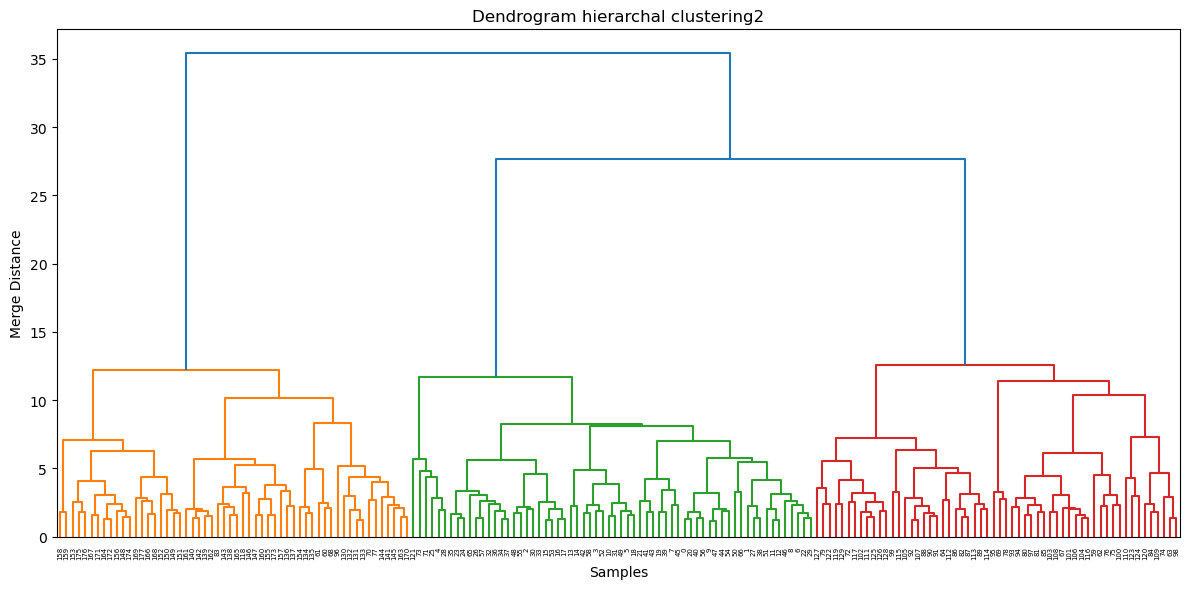

In [25]:
Z = linkage(X_scaled, method="ward")
plt.figure(figsize = (12,6))
dendrogram(Z)
plt.title("Dendrogram hierarchal clustering2")
plt.xlabel("Samples")
plt.ylabel("Merge Distance")
plt.tight_layout()
plt.show()

In [27]:
n_clusters = 3
hc = AgglomerativeClustering(
    n_clusters = n_clusters,
    linkage = "ward"
)
labels = hc.fit_predict(X_scaled)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

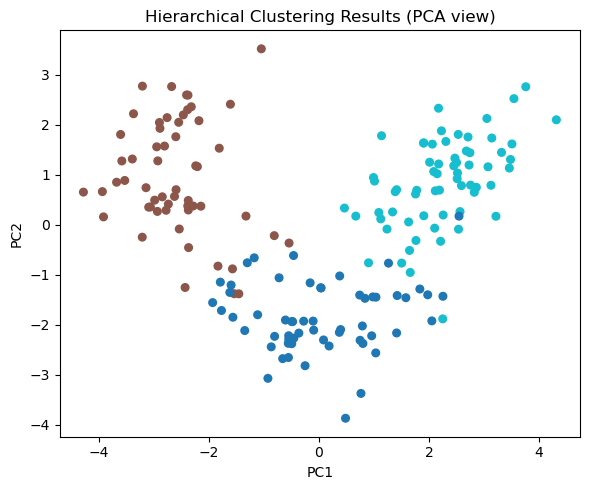

In [28]:
# -------------------------------------------------------------
# # 4) Reduce to 2D for visualization of clusters
# -------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=30)
plt.title("Hierarchical Clustering Results (PCA view)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [29]:
print("Cluster Counts",np.bincount(labels))

Cluster Counts [58 56 64]


Dimensionality Reduction Concept

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

# Load dataset (13 features -> good for dimensionality reduction)
data = load_wine()
X = data.data
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [2]:
# Apply PCA (reduce from 13D to 2D)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_reduced.shape)

Original Shape: (178, 13)
Reduced Shape: (178, 2)


In [3]:
# Variance information
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:", explained_variance)


Explained Variance Ratio: [0.99809123 0.00173592]


In [4]:
total_variance_preserved = np.sum(explained_variance)
print("Total Variance Preserved:", total_variance_preserved)

Total Variance Preserved: 0.9998271461166031


In [5]:
information_loss = 1 - total_variance_preserved
print("Information Loss:", information_loss)

Information Loss: 0.00017285388339693952


mplementation with Scikit-Learn - Part I

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: load dataset (30 features)
data = load_breast_cancer()
X = data.data
y = data.target
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [7]:
# Step 2: Standardize features (critical for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [8]:
# Step 3: Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

In [9]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.44272026 0.18971182]


In [10]:
print("Total Variance Preserved:", np.sum(pca.explained_variance_ratio_))

Total Variance Preserved: 0.6324320765155943


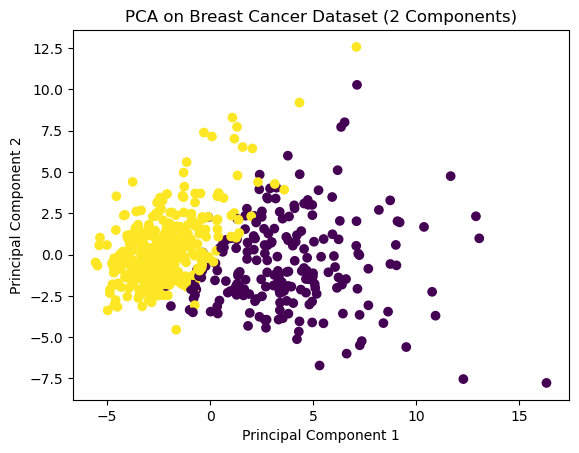

In [11]:
# Step 5: Visualize PCA result
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Breast Cancer Dataset (2 Components)")
plt.show()

Implementation with Scikit-Learn - Part II

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load dataset (64 features)
digits = load_digits()
X = digits.data
y = digits.target
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [13]:
# Step 2: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

In [14]:
# Step 3: Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-1.91421366, -0.95450157],
       [-0.58898033,  0.9246358 ],
       [-1.30203906, -0.31718883],
       ...,
       [-1.02259599, -0.14791087],
       [-1.07605522, -0.38090625],
       [ 1.25770233, -2.22759088]], shape=(1797, 2))

In [15]:
# Step 4: Evaluate dimensionality reduction
print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (1797, 64)
Reduced Shape: (1797, 2)


In [16]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.12033916 0.09561054]


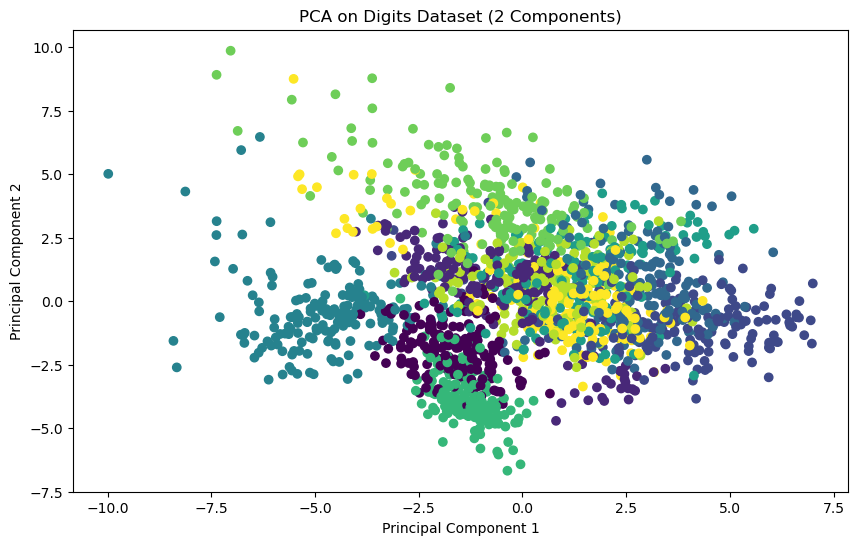

In [17]:
# Step 5: Visualize PCA result
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Digits Dataset (2 Components)")
plt.show()